In [1]:
################################################
###
### test SH decomposition with Hannah organoid data
###
################################################

In [2]:
from skimage import measure
import pandas as pd
from skimage.filters import threshold_otsu, rank
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pyshtools as pysh

In [4]:
from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
import matplotlib.pyplot as plt

In [5]:
import napari
from napari.utils import nbscreenshot

In [6]:
cle.available_device_names()

['Apple M1 Max']

In [7]:
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/image_env/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [8]:
### import function https://github.com/gioda/FeARLesS/blob/main/Fearless/utils.py
import pyshtools
import gc
import numpy as np
import os
from vedo import printc, spher2cart, probePoints

#from vedo import Points
import shutil
from sys import exit
#from vedo import spher2cart
#from vedo import printc, spher2cart, probePoints

In [9]:
def samplePoints(vol, expo, N, radiusDiscretisation):
    """Compute sample points."""
    pos = vol.center()
    rmax = vol.diagonalSize()/2

    samplePoints = []
    for th in np.linspace(0, np.pi, N, endpoint=False):
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):

            # compute sample points
            p = spher2cart(rmax, th, ph)
            # making discretization more dense away from the center
            p_tmp = p / (radiusDiscretisation-1)**expo
            for j in range(radiusDiscretisation):
                SP = pos + p_tmp * (j**expo)
                samplePoints.append(SP)

    del vol
    return np.array(samplePoints)

def confirm(message):
    """
    Ask user to enter Y or N (case-insensitive).

    :return: True if the answer is Y.
    :rtype: bool
    """
    answer = ""
    while answer not in ["y", "n"]:
        answer = input(message).lower()
    return answer == "y"


def pathExists(path):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        printc("Directory ", path, " Created ", c='green')
    else:
        printc("Directory ", path, " already exists", c='red')
        if confirm("Should I delete the folder and create a new one [Y/N]? "):
            shutil.rmtree(path)
            os.makedirs(path, exist_ok=True)
            printc("Directory ", path, " Created ", c='green')
        else:
            exit()


def voxelIntensity(vol, expo, N, radiusDiscretisation):
    """Compute voxel intensities."""
    pos = vol.center()
    rmax = vol.diagonalSize()/2

    scalars = []

    for th in np.linspace(0, np.pi, N, endpoint=False):
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):

            # compute sample points
            p = spher2cart(rmax, th, ph)
            samplePointsTmp = []
            
            # making discretization more dense away from the center
            p_tmp = p / (radiusDiscretisation-1)**expo
            for j in range(radiusDiscretisation):
                SP = pos + p_tmp * (j**expo)
                samplePointsTmp.append(SP)

            # compute intensities
            pb = probePoints(vol, samplePointsTmp)

            del samplePointsTmp

            # making the intensities growing outside the volume according to the gradient
            scalarsTmp = pb.getPointArray()
            nonz = np.nonzero(scalarsTmp)[0]
            if len(nonz) > 2:
                lastNoZeroId = nonz[-1]  # find the last value != 0
                secondlastNoZeroId = nonz[-2]
                # find the last value != 0
                lastNoZero = scalarsTmp[lastNoZeroId]
                secondlastNoZero = scalarsTmp[secondlastNoZeroId]
                dx = lastNoZero - secondlastNoZero

            for i in range(lastNoZeroId+1, len(scalarsTmp)):
                scalarsTmp[i] = scalarsTmp[i-1] + dx
            scalars.append(scalarsTmp.tolist())

            del pb, scalarsTmp

    del vol
    gc.collect()

    # return allIntensitiesMatrix
    return np.array(scalars).reshape((N * N, radiusDiscretisation))


def forwardTransformation(matrixOfIntensities, N, lmax):

    ##############################################

    coeff = matrixOfIntensities

    ##############################################
    # SPHARNM
    allClm = np.zeros((matrixOfIntensities.shape[1], 2, lmax, lmax))
    for j in range(allClm.shape[0]):
        formattedcoeff = np.reshape(coeff[:, j], (N, N))
        SH = pyshtools.SHGrid.from_array(formattedcoeff)
        clm = SH.expand()

        allClm[j, :, :, :] = clm.to_array(lmax=lmax - 1)

    del formattedcoeff, clm, matrixOfIntensities

    return allClm


def inverseTransformations(allClm, allIntensitiesShape, N, lmax):
    """Make inverse SPHARM."""
    from scipy.interpolate import griddata

    aSH_recoMatrix = np.zeros((allIntensitiesShape[0], allIntensitiesShape[1]))

    for j in range(allClm.shape[0]):
        # inverse SPHARM coefficients
        clmCoeffs = pyshtools.SHCoeffs.from_array(allClm[j, :, :, :])
        SH_reco = clmCoeffs.expand(lmax=lmax - 1)
        # grid_reco.plot()
        aSH_reco = SH_reco.to_array()

        ##############################
        pts1 = []
        ll = []
        for ii, long in enumerate(np.linspace(0, 360, num=aSH_reco.shape[1], endpoint=True)):
            for jj, lat in enumerate(np.linspace(90, -90, num=aSH_reco.shape[0], endpoint=True)):
                th = np.deg2rad(90 - lat)
                ph = np.deg2rad(long)
                p = spher2cart(aSH_reco[jj][ii], th, ph)
                pts1.append(p)
                ll.append((lat, long))

        radii = aSH_reco.T.ravel()

        # make a finer grid
        n = N * 1j
        l_min, l_max = np.array(ll).min(axis=0), np.array(ll).max(axis=0)
        grid = np.mgrid[l_max[0]:l_min[0]:n, l_min[1]:l_max[1]:n]
        grid_x, grid_y = grid
        agrid_reco_finer = griddata(ll, radii, (grid_x, grid_y), method='cubic')
        ##############################

        formatted_aSH_reco = np.reshape(agrid_reco_finer, (N * N))

        aSH_recoMatrix[:, j] = formatted_aSH_reco

    del formatted_aSH_reco, agrid_reco_finer, grid_x, grid_y, grid

    return aSH_recoMatrix


In [10]:
from sys import argv, exit
import numpy as np
import pyshtools

from vedo import printc, load, spher2cart, mag, ProgressBar, Points, write
from vedo import *

from skimage.io import imread
from skimage.io import imsave
#from skimage import filters
#from skimage import morphology
#from pyclesperanto_prototype import imshow
#import pyclesperanto_prototype as cle
#import matplotlib.pyplot as plt

#from scipy.interpolate import griddata

In [11]:
def computeCLM(mesh, rmax, N, x0):
    """Compute CLM."""
    # cast rays from the center and find intersections
    agrid, pts = [], []
    for th in np.linspace(0, np.pi, N, endpoint=False):
        lats = []
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
            p = spher2cart(rmax, th, ph)
            intersections = mesh.intersect_with_line(x0, x0 + p)
            if len(intersections):
                value = mag(intersections[0]-x0)
                lats.append(value)
                pts.append(intersections[0])
            else:
                lats.append(rmax)
                # lats.append(0)
                pts.append(p)
        agrid.append(lats)
    agrid = np.array(agrid)

    grid = pyshtools.SHGrid.from_array(agrid)
    clm = grid.expand()
    # grid_reco = clm.expand(lmax=lmax)  # cut "high frequency" components

    return clm

In [13]:
lmax = 20
N = 500          # number of grid intervals on the unit sphere
rmax = 1400
x0 = [0, 0, 0]  # set object at this position
xLimb = [-200, 0, 200]
cutOrigin = [150, 0, 0]
deg_fit = 6

In [14]:
CPoutDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/d4_WT"
WTDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/d4_WT" 

#CPoutDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/CPouts2"
#ImageDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/d4_10x_Pax6KO_WTchim" 

In [19]:
#DataPath = '/Users/jingkui.wang/workspace/imp/image_analysis/S-BIAD441/limbs/limbs-noFlank/'
path_results = 'res/' + 'test_organoid_WTd4' + '/'

#pathExists(path_results)

printc('lmax =', lmax, 'N =', N, 'deg_fit =', deg_fit, c='y')

lmax = 20 N = 200 deg_fit = 6


In [20]:
from skimage import measure
import pandas as pd
from skimage.filters import threshold_otsu, rank
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from vedo import printc, load, ProgressBar
#from utils import pathExists, voxelIntensity
import numpy as np
import gc
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for non-interactive plotting

import matplotlib.pyplot as plt

In [21]:
radiusDiscretisation = 50
N = 200
FFTexpansion = radiusDiscretisation
expo = 1.0
#print(outDir)

In [22]:
from itertools import chain  
col_names =  [['image', 'cyst_index', 'cyst_size', 'cyst_r'], ['power_per_l'+i for i in map(str, range(lmax+1))], ['power_per_lm'+i for i in map(str, range(lmax+1))]]
col_names = list(chain(*col_names))  
#col_names

In [ ]:
#CPoutDir = "../images_data/CPouts2"
for nm in os.listdir(CPoutDir):
    if "_C4_CystMask.tiff" in nm:
        #print(nm)
        df = pd.DataFrame(columns = col_names)
        #df
        fileName = nm.replace('_C4_CystMask.tiff','')
        
        outDir = os.path.join(path_results, str(fileName + '/'))
        if not os.path.exists(outDir):
            os.makedirs(outDir)
        
        #files += [nm]
        print(fileName)
        #make_composite_C5(newName, ImageDir, outDir)
        mask = imread(os.path.join(CPoutDir, str(fileName + "_C4_CystMask.tiff"))) # mask segmeted cysts
        C3 = imread(os.path.join(WTDir, str(fileName + "_C3.tif"))) # FoxA2, nuclei
        C2 = imread(os.path.join(WTDir, str(fileName + "_C2.tif"))) # Pax6, nuclei
        C4 = imread(os.path.join(WTDir, str(fileName + "_C4.tif"))) # Dapi, nuclei
        
        labels_mask, nb_cyst = measure.label(mask, return_num = True)
        
        # for each orgnoid
        for i in range(nb_cyst+1):
            if i > 0:
                
                cyst_select = np.where(labels_mask == i)
                cyst_index = i
                
                if cyst_select[0].size > 100: # orgnoid must > 100
                    # find the boundary of the orgnoid
                    [z, rows, columns] = np.where(labels_mask == cyst_index)
                    z1 = min(z)
                    z2 = max(z)
                    row1 = min(rows)
                    row2 = max(rows)
                    col1 = min(columns)
                    col2 = max(columns)
                
                    # crop the orgnoid and save foxa2 and dapi
                    xx = np.where(labels_mask == cyst_index, C3, 0)
                    newImage_foxa2 = xx[z1:z2, row1:row2, col1:col2]
                
                    xx = np.where(labels_mask == cyst_index, C4, 0)
                    newImage_dapi = xx[z1:z2, row1:row2, col1:col2]

                    xx = np.where(labels_mask == cyst_index, labels_mask, 0)
                    newImage_cyst = xx[z1:z2, row1:row2, col1:col2]
                
                    imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
                    imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
                    
                    del xx, newImage_dapi, newImage_cyst, newImage_foxa2, z1, z2, row1, row2, col1, col2
                    
                    # reload the dapi and foxa2 using vedo
                    vol_foxa2 = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")))
                    vol_dapi = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")))
                
                    # the center and radius of organoid
                    pos = vol_dapi.center()
                    rmax = vol_dapi.diagonalSize()/2
                
                    # Compute voxel intensities
                    scalars = []
                    for th in np.linspace(0, np.pi, N, endpoint=False):
                        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
        
                            # compute sample points
                            p = spher2cart(rmax, th, ph)
        
                            samplePointsTmp = []
                            # making discretization more dense away from the center
                            p_tmp = p / (radiusDiscretisation-1)**expo
                        
                            for j in range(radiusDiscretisation):
                                SP = pos + p_tmp * (j**expo)
                                samplePointsTmp.append(SP)

                            # compute intensities
                            pb = probePoints(vol_foxa2, samplePointsTmp)

                            scalarsTmp = pb.getPointArray()
        
                            scalars.append(scalarsTmp.max())
            
                            del pb, scalarsTmp, samplePointsTmp, p, p_tmp
                            #gc.collect()


                    matrixOfIntensities = np.array(scalars)
                    #coeff = matrixOfIntensities
                    #matrixOfIntensities
                    #len(matrixOfIntensities)
                    formattedcoeff = np.reshape(matrixOfIntensities, (N, N))
                    
                    # remove the mean to reduce the l=0 contribution
                    formattedcoeff_norm = formattedcoeff - formattedcoeff.mean()
                    
                    SH = pyshtools.SHGrid.from_array(formattedcoeff_norm, grid = "DH")
                    clm = SH.expand(lmax_calc= lmax)
                    #grid_reco = clm.expand(lmax=lmax).to_array()  # cut "high frequency" components
                    grid = clm.expand(lmax = 20)
                    
                    Plot_intermediate = True
                    if Plot_intermediate: 
                        fig, ax = plt.subplots(1, 1)
                        ax.imshow(formattedcoeff, extent=(0, N, 0, N))
                        ax.set(xlabel='theta', ylabel='phi')
                        #plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity.pdf")))
                        plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity_" + str(cyst_index)+".pdf")))
                    
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        fig, ax = clm.plot_spectrum(show=False, lmax = 10, convention = 'power', unit = "per_lm")
                        plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_lm_" + str(cyst_index)+".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        fig, ax = clm.plot_spectrum(show=False, lmax = 10, convention = 'power', unit = "per_l")
                        plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_l_" + str(cyst_index)+ ".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        fig, ax = clm.plot_spectrum2d(show=False, lmax = 10)
                        plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_2d_per_l_m_"+ str(cyst_index)+".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        
                        fig, ax = grid.plot(show=False)
                        plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2Intensity_restored_with20Components_"+ str(cyst_index)+".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        plt.close('all')
                        gc.collect();
                    
                    del scalars, matrixOfIntensities, formattedcoeff
                    #gc.collect()
                    
                    # save the SH power 
                    df.loc[len(df)] =  list(chain([fileName, cyst_index, cyst_select[0].size, rmax], 
                                              clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"), 
                                              clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l")))
                    
                    del SH, clm, grid, cyst_select, vol_foxa2, vol_dapi
                    #gc.collect()
                    
        df.to_csv(os.path.join(outDir, "Condion_echOrgnoid_SHspectrum_power.csv"), index=True, header=True)
        del mask, C2, C3, C4, df, labels_mask, nb_cyst
        #gc.collect()

20220726_d4_10x_RA-18h_E2_121_1745_isotropic


/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_121_1745_isotropic/20220726_d4_10x_RA-18h_E2_121_1745_isotropic_cyst_2_channel_FoxA2_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:51: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_121_1745_isotropic/20220726_d4_10x_RA-18h_E2_121_1745_isotropic_cyst_2_channel_dapi_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_121_1745_isotropic/20220726_d4_10x_RA-18h_E2_121_1745_isotropic_cyst_2_channel_FoxA2_2.tif is a low contrast

20220726_d4_10x_RA-18h_E2_122_1746_isotropic


/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_122_1746_isotropic/20220726_d4_10x_RA-18h_E2_122_1746_isotropic_cyst_2_channel_FoxA2_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:51: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_122_1746_isotropic/20220726_d4_10x_RA-18h_E2_122_1746_isotropic_cyst_2_channel_dapi_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_122_1746_isotropic/20220726_d4_10x_RA-18h_E2_122_1746_isotropic_cyst_2_channel_FoxA2_2.tif is a low contrast

20220726_d4_10x_RA-18h_E2_123_1747_isotropic


/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_123_1747_isotropic/20220726_d4_10x_RA-18h_E2_123_1747_isotropic_cyst_2_channel_FoxA2_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:51: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_123_1747_isotropic/20220726_d4_10x_RA-18h_E2_123_1747_isotropic_cyst_2_channel_dapi_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_123_1747_isotropic/20220726_d4_10x_RA-18h_E2_123_1747_isotropic_cyst_2_channel_FoxA2_2.tif is a low contrast

20220726_d4_10x_RA-18h_E2_124_1748_isotropic


/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_124_1748_isotropic/20220726_d4_10x_RA-18h_E2_124_1748_isotropic_cyst_2_channel_FoxA2_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:51: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_124_1748_isotropic/20220726_d4_10x_RA-18h_E2_124_1748_isotropic_cyst_2_channel_dapi_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_62004/1957840356.py:50: UserWarning: res/test_organoid_WTd4/20220726_d4_10x_RA-18h_E2_124_1748_isotropic/20220726_d4_10x_RA-18h_E2_124_1748_isotropic_cyst_2_channel_FoxA2_2.tif is a low contrast

In [ ]:
#del pb, scalarsTmp, samplePointsTmp


In [31]:
fileName, i
cyst_index
str(cyst_index)

'1'

In [34]:
cyst_index_string =  "%s" % cyst_index
imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_6600/340781571.py:2: UserWarning: res/test_organoid_WTd6/20220727_d6_10x_RA-18h_E2_121_1981_isotropic_cyst_2_channel_FoxA2_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)


In [47]:
outDir = path_results
fileName = '20220727_d6_10x_RA-18h_E2_121_1981_isotropic'
#fileName = '241023_10x_d4-2umZ_4-PS-WG_RA_FA2-Px6_F9_95_01_isotropic'

In [48]:
mask = imread(os.path.join(CPoutDir, str(fileName + "_C4_CystMask.tiff"))) # mask segmeted cysts
C3 = imread(os.path.join(WTDir, str(fileName + "_C3.tif"))) # FoxA2, nuclei
C2 = imread(os.path.join(WTDir, str(fileName + "_C2.tif"))) # Pax6, nuclei
C4 = imread(os.path.join(WTDir, str(fileName + "_C4.tif"))) # Dapi, nuclei

#C3 = C3 / np.quantile(C3, 0.95)
#C2 = C2 / np.quantile(C2, 0.95)
#C4 = C4 / np.quantile(C4, 0.95)

In [49]:
#mask = imread(os.path.join(CPoutDir, str(fileName + "_C5_CystMask.tiff"))) # mask segmeted cysts
#C1 = imread(os.path.join(CPoutDir, str(fileName + "_FoxA2mask.tiff"))) # FoxA2, nuclei
#C2 = imread(os.path.join(CPoutDir, str(fileName + "_P6KOSCmask.tiff"))) # Pax6-KO genotype Scarlet, nuclei
#C3 = imread(os.path.join(CPoutDir, str(fileName + "_WTGFPmask.tiff"))) # WT genotype GFP, whole cell 
#C4 = imread(os.path.join(CPoutDir, str(fileName + "_Pax6mask.tiff"))) # Pax6, nuclei
#C1 = imread(os.path.join(ImageDir, str(fileName + "_C1.tif"))) # FoxA2, nuclei
#C2 = imread(os.path.join(ImageDir, str(fileName + "_C2.tif"))) # Pax6-KO genotype Scarlet, nuclei
#C3 = imread(os.path.join(ImageDir, str(fileName + "_C3.tif"))) # WT genotype GFP, whole cell 
#C4 = imread(os.path.join(ImageDir, str(fileName + "_C4.tif"))) # Pax6, nuclei
#C1 = C1 / np.quantile(C1, 0.99)
#C2 = C2 / np.quantile(C2, 0.99)
#C3 = C3 / np.quantile(C3, 0.99)
#C4 = C4 / np.quantile(C4, 0.99)

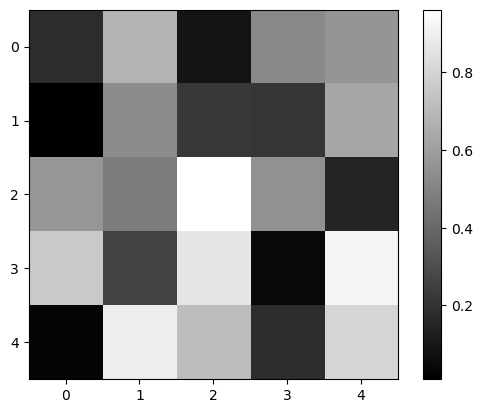

In [50]:
## test the image data structure in skimage
## for volumetric (3D) images, we refer to the leading dimension as plane, abbreviated as pln or p.
## 3D grayscale the numpy data structure is: (plane, row, column)

random_image = np.random.random([5, 5])
plt.imshow(random_image, cmap='gray')
plt.colorbar();

In [51]:
random_image 

array([[0.17877855, 0.67648187, 0.08594899, 0.52084949, 0.56504695],
       [0.00980597, 0.53150506, 0.22520949, 0.21257298, 0.63226329],
       [0.56784191, 0.47359802, 0.96140439, 0.5494939 , 0.14625024],
       [0.75780646, 0.25917989, 0.86781358, 0.04001109, 0.92055398],
       [0.02701702, 0.89159043, 0.71551065, 0.17927926, 0.80222969]])

In [52]:
from skimage import measure
import pandas as pd
from skimage.filters import threshold_otsu, rank
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [53]:
labels_mask, nb_cyst = measure.label(mask, return_num = True)

In [54]:
#from skimage.measure import label, regionprops
#props = regionprops(labels_mask)
#props
#props[0].pixelcount

In [55]:
nb_cyst

29

In [56]:
cyst_index = np.where(labels_mask == 27)
cyst_index[0].size
#genotype_wt = C3[cyst_index]
#genotype_ko = C2[cyst_index]

264

In [57]:
cyst_index = 10

In [58]:
cyst_select = np.where(labels_mask == cyst_index)
cyst_select[0].size

95612

In [59]:
viewer = napari.Viewer()

# show images
viewer.add_image(cle.pull(C3))
viewer.add_labels(cle.pull(labels_mask))

<Labels layer 'labels_mask' at 0x841d140d60>

2025-03-17 13:54:57.041 python[6600:203318720] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-17 13:54:57.041 python[6600:203318720] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [60]:
[z, rows, columns] = np.where(labels_mask == cyst_index)
z1 = min(z)
z2 = max(z)
row1 = min(rows)
row2 = max(rows)
col1 = min(columns)
col2 = max(columns)

In [61]:
xx = np.where(labels_mask == cyst_index, C3, 0)
newImage_foxa2 = xx[z1:z2, row1:row2, col1:col2]

xx = np.where(labels_mask == cyst_index, C4, 0)
newImage_dapi = xx[z1:z2, row1:row2, col1:col2]

xx = np.where(labels_mask == cyst_index, labels_mask, 0)
newImage_cyst = xx[z1:z2, row1:row2, col1:col2]


In [62]:
newImage_foxa2.shape, newImage_dapi.shape


((53, 61, 59), (53, 61, 59))

In [63]:
newImage_cyst.shape
print(newImage_foxa2.min())
print(newImage_foxa2.max())
print(newImage_dapi.min())
print(newImage_dapi.max())

0
4049
0
14142


In [64]:
imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2.tif")), newImage_foxa2)
imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi.tif")), newImage_dapi)

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_6600/1337608745.py:1: UserWarning: res/test_organoid_WTd6/20220727_d6_10x_RA-18h_E2_121_1981_isotropic_cyst_2_channel_FoxA2.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2.tif")), newImage_foxa2)


In [65]:
outDir

'res/test_organoid_WTd6/'

In [66]:
viewer = napari.Viewer()
# show images
viewer.add_image(cle.pull(newImage_cyst))
viewer.add_image(cle.pull(newImage_foxa2))
viewer.add_image(cle.pull(newImage_dapi))

<Image layer 'newImage_dapi' at 0x842fc0c670>

In [71]:
## from here test the code from fearless

In [67]:
from vedo import printc, load, ProgressBar
#from utils import pathExists, voxelIntensity
import numpy as np

In [68]:
radiusDiscretisation = 50
N = 250
FFTexpansion = radiusDiscretisation
expo = 1.0

In [69]:
newImage_dapi.shape

(53, 61, 59)

In [70]:
vol_dapi = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi.tif")))
vol_foxa2 = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2.tif")))

In [71]:
pos = vol_dapi.center()
rmax = vol_dapi.diagonalSize()/2
pos, rmax, N, radiusDiscretisation

(array([29., 30., 26.]), 49.16299421312742, 250, 50)

In [153]:
mesh = Sphere(pos=pos, r=rmax, c='r5', res=24)
show(mesh, vol_foxa2).close()
#show(vol_obj, arrs+arrs_pts_probe, N=2, axes=1).close()

In [154]:
show(vol_dapi).close()

In [155]:
scalars = []

In [156]:
np.linspace(0, np.pi, N, endpoint=False);
np.linspace(0, 2*np.pi, N, endpoint=False);
th = np.linspace(0, np.pi, N, endpoint=False)[100]
ph = np.linspace(0, 2*np.pi, N, endpoint=False)[20]
th, ph

(1.2566370614359172, 0.5026548245743669)

In [53]:
p = spher2cart(rmax, th, ph)
p,pos

(array([40.97328392, 22.52525345, 15.19220071]), array([29., 30., 26.]))

In [54]:
p_tmp = p / (radiusDiscretisation-1)**expo

samplePointsTmp = []
for j in range(radiusDiscretisation):
    SP = pos + p_tmp * (j**expo) # pos is the center, 
    samplePointsTmp.append(SP)

len(samplePointsTmp), p, p_tmp, (radiusDiscretisation-1)**expo

(50,
 array([40.97328392, 22.52525345, 15.19220071]),
 array([0.83618947, 0.45969905, 0.31004491]),
 49.0)

In [55]:
samplePointsTmp;

In [56]:
pb = probePoints(vol_foxa2, samplePointsTmp)
#del samplePointsTmp
scalarsTmp = pb.getPointArray()
scalarsTmp

array([452, 495, 489, 464, 467, 474, 459, 443, 436, 420, 422, 428, 413,
       407, 385, 377, 375, 378, 377, 352, 326, 323, 308, 284, 285, 284,
       277, 267, 261, 245,  57,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
      dtype=uint16)

In [57]:
scalarsTmp = pb.getPointArray()

nonz = np.nonzero(scalarsTmp)[0]
scalarsTmp;
nonz

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [58]:
lastNoZeroId = nonz[-1]  # find the last value != 0
secondlastNoZeroId = nonz[-2]
lastNoZeroId, secondlastNoZeroId

(30, 29)

In [59]:
lastNoZero = scalarsTmp[lastNoZeroId]
secondlastNoZero = scalarsTmp[secondlastNoZeroId]
dx = lastNoZero - secondlastNoZero
lastNoZero,secondlastNoZero

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_8819/307586485.py:3: RuntimeWarning: overflow encountered in scalar subtract
  dx = lastNoZero - secondlastNoZero


(57, 245)

In [60]:
scalarsTmp.max().tolist()

495

In [72]:
N = 200; radiusDiscretisation = 50

In [73]:
#scalarsTmp.max()

In [74]:
"""Compute voxel intensities."""
scalars = []
for th in np.linspace(0, np.pi, N, endpoint=False):
    for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
        
        # compute sample points
        p = spher2cart(rmax, th, ph)
        
        samplePointsTmp = []
        # making discretization more dense away from the center
        p_tmp = p / (radiusDiscretisation-1)**expo
        for j in range(radiusDiscretisation):
            SP = pos + p_tmp * (j**expo)
            samplePointsTmp.append(SP)

        # compute intensities
        pb = probePoints(vol_foxa2, samplePointsTmp)
        
        del samplePointsTmp

        # making the intensities growing outside the volume according to the gradient
        scalarsTmp = pb.getPointArray()
        #nonz = np.nonzero(scalarsTmp)[0]
        #print(scalarsTmp)
        
        #if len(nonz) > 2:
        #    lastNoZeroId = nonz[-1]  # find the last value != 0
        #    secondlastNoZeroId = nonz[-2]
        #    # find the last value != 0
        #    lastNoZero = scalarsTmp[lastNoZeroId]
        #    secondlastNoZero = scalarsTmp[secondlastNoZeroId]
        #    dx = lastNoZero - secondlastNoZero

        #for i in range(lastNoZeroId+1, len(scalarsTmp)):
        #    scalarsTmp[i] = scalarsTmp[i-1] + dx
        
        scalars.append(scalarsTmp.max())
        del pb, scalarsTmp

    #del vol
    #gc.collect()

    # return allIntensitiesMatrix
    #return np.array(scalars).reshape((N * N, radiusDiscretisation))

In [75]:
len(scalars)

40000

In [76]:
matrixOfIntensities = np.array(scalars)
coeff = matrixOfIntensities
matrixOfIntensities
len(matrixOfIntensities)

40000

In [77]:
#coeff = matrixOfIntensities
##############################################
# SPHARNM
#allClm = np.zeros((matrixOfIntensities.shape[1], 2, lmax, ))

In [78]:
formattedcoeff = np.reshape(coeff, (N, N))
formattedcoeff

array([[452, 452, 452, ..., 452, 452, 452],
       [452, 452, 452, ..., 452, 452, 452],
       [452, 452, 452, ..., 452, 452, 452],
       ...,
       [474, 474, 474, ..., 473, 473, 473],
       [476, 476, 476, ..., 475, 475, 475],
       [477, 478, 478, ..., 477, 477, 477]], dtype=uint16)

In [79]:
fig, ax = plt.subplots(1, 1)
ax.imshow(formattedcoeff, extent=(0, N, 0, N))
ax.set(xlabel='theta', ylabel='phi')
#ax.minorticks_on()
plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity.pdf")))
plt.close()

[Text(0.5, 0, 'theta'), Text(0, 0.5, 'phi')]

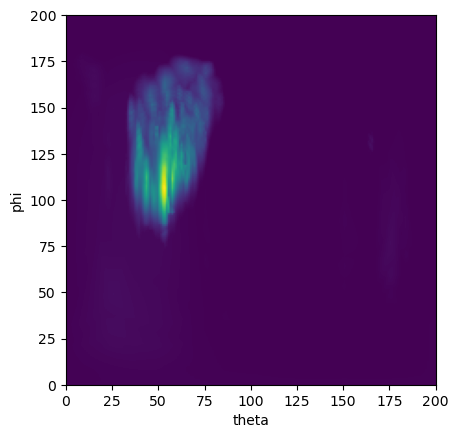

In [80]:
formattedcoeff_norm = formattedcoeff - formattedcoeff.mean()
fig, ax = plt.subplots(1, 1)
ax.imshow(formattedcoeff_norm, extent=(0, N, 0, N))
ax.set(xlabel='theta', ylabel='phi')
#ax.minorticks_on()

In [82]:
fileName


'20220727_d6_10x_RA-18h_E2_121_1981_isotropic'

In [83]:
formattedcoeff_norm

array([[-95.200425, -95.200425, -95.200425, ..., -95.200425, -95.200425,
        -95.200425],
       [-95.200425, -95.200425, -95.200425, ..., -95.200425, -95.200425,
        -95.200425],
       [-95.200425, -95.200425, -95.200425, ..., -95.200425, -95.200425,
        -95.200425],
       ...,
       [-73.200425, -73.200425, -73.200425, ..., -74.200425, -74.200425,
        -74.200425],
       [-71.200425, -71.200425, -71.200425, ..., -72.200425, -72.200425,
        -72.200425],
       [-70.200425, -69.200425, -69.200425, ..., -70.200425, -70.200425,
        -70.200425]])

In [84]:
lmax

20

In [85]:
SH = pyshtools.SHGrid.from_array(formattedcoeff_norm, grid = "DH")
clm = SH.expand(lmax_calc= lmax)
grid_reco = clm.expand(lmax=lmax).to_array()  # cut "high frequency" components

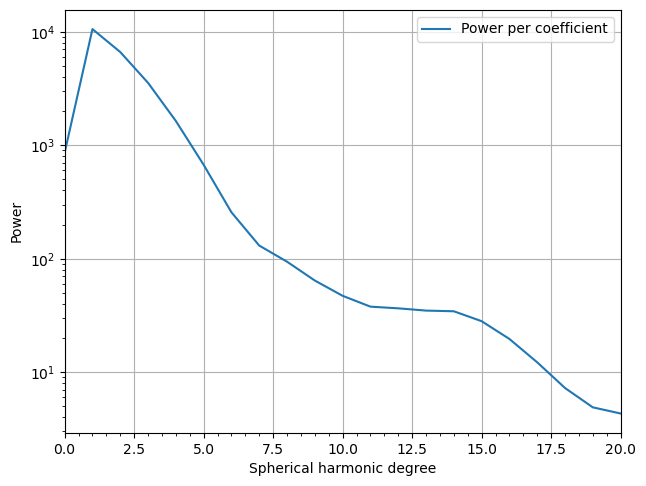

In [87]:
fig, ax = clm.plot_spectrum(show=False, lmax = 20, convention = 'power', unit = "per_lm")
plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_lm.pdf")))

In [88]:
clm.spectrum(lmax = 20, convention = 'power', unit = "per_lm")

array([8.60235858e+02, 1.05812104e+04, 6.64193902e+03, 3.55280243e+03,
       1.63808851e+03, 6.72598384e+02, 2.56308683e+02, 1.30489754e+02,
       9.40323506e+01, 6.41062082e+01, 4.70202059e+01, 3.77398675e+01,
       3.64713370e+01, 3.48331768e+01, 3.43588117e+01, 2.80926260e+01,
       1.95785234e+01, 1.21813195e+01, 7.23239998e+00, 4.88356235e+00,
       4.30916791e+00])

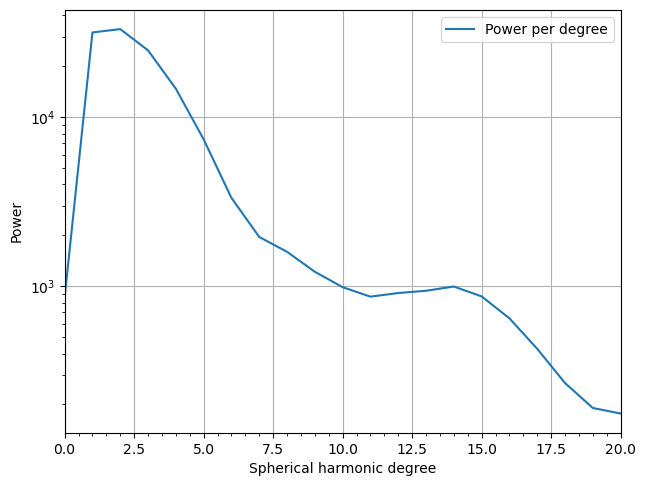

In [89]:
fig, ax = clm.plot_spectrum(show=False, lmax = 20, convention = 'power', unit = "per_l")
plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_l.pdf")))

In [90]:
clm.spectrum(lmax = 20, convention = 'power', unit = "per_l")

array([  860.23585813, 31743.63108853, 33209.6951116 , 24869.61700631,
       14742.79659634,  7398.58222811,  3332.01288221,  1957.34630259,
        1598.54995962,  1218.01795571,   987.42432468,   868.01695239,
         911.78342431,   940.49577269,   996.40554008,   870.87140596,
         646.0912707 ,   426.34618202,   267.59879929,   190.4589316 ,
         176.67588429])

In [91]:
#clm.to_array(lmax = 20);

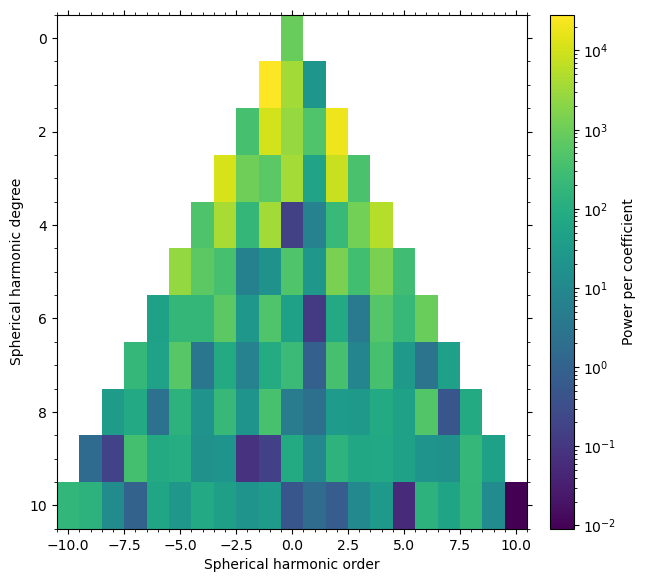

In [92]:
fig, ax = clm.plot_spectrum2d(show=False, lmax = 10)
plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_2d_per_l_m.pdf")))

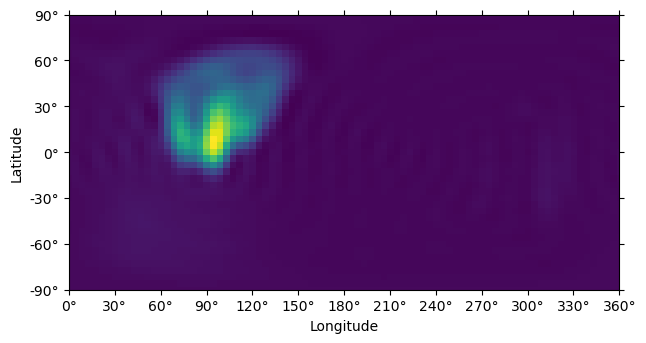

In [93]:
grid = clm.expand(lmax = 20)
fig, ax = grid.plot(show=False)
plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2Intensity_restored_with20Components.pdf")))

In [156]:
import pandas as pd
from itertools import chain  
col_names =  [['image', 'cyst_index', 'cyst_r'], ['power_per_l'+i for i in map(str, range(lmax+1))], ['power_per_lm'+i for i in map(str, range(lmax+1))]]
#data = {"image": [], "cyst_index": [], "cyst_r": [],  "pct_genotype": [], "pct_wt": [], "pct_foxa2": [], "pct_pax6": [],  
#        "cutoff_wt": [],  "cutoff_ko": [],  "cutoff_foxa2": [],  "cutoff_pax6": []}
#df = pd.DataFrame(columns = col_names)
#df = pd.DataFrame(data)
#df
col_names = list(chain(*col_names))  
col_names
df = pd.DataFrame(columns = col_names)
df

,image,cyst_index,cyst_r,power_per_l0,power_per_l1,power_per_l2,power_per_l3,power_per_l4,power_per_l5,power_per_l6,...,power_per_lm11,power_per_lm12,power_per_lm13,power_per_lm14,power_per_lm15,power_per_lm16,power_per_lm17,power_per_lm18,power_per_lm19,power_per_lm20


In [145]:
#['string'+i for i in map(str, range(10))]

['string0',
 'string1',
 'string2',
 'string3',
 'string4',
 'string5',
 'string6',
 'string7',
 'string8',
 'string9']

In [88]:
df

,image,cyst_index,cyst_size,cyst_r,power_per_l0,power_per_l1,power_per_l2,power_per_l3,power_per_l4,power_per_l5,...,power_per_lm11,power_per_lm12,power_per_lm13,power_per_lm14,power_per_lm15,power_per_lm16,power_per_lm17,power_per_lm18,power_per_lm19,power_per_lm20


In [102]:
df.loc[len(df)] = list(chain([fileName, cyst_index, cyst_select[0].size, rmax], clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"), clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l")))

In [103]:
df

,image,cyst_index,cyst_size,cyst_r,power_per_l0,power_per_l1,power_per_l2,power_per_l3,power_per_l4,power_per_l5,...,power_per_lm11,power_per_lm12,power_per_lm13,power_per_lm14,power_per_lm15,power_per_lm16,power_per_lm17,power_per_lm18,power_per_lm19,power_per_lm20
0,20220727_d6_10x_RA-18h_E2_121_1981_isotropic,10,95612,49.162994,860.235858,10581.210363,6641.939022,3552.802429,1638.088511,672.598384,...,868.016952,911.783424,940.495773,996.40554,870.871406,646.091271,426.346182,267.598799,190.458932,176.675884


In [101]:
list(chain([fileName, cyst_index, cyst_select[0].size, rmax], clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"), clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l")))

['20220727_d6_10x_RA-18h_E2_121_1981_isotropic',
 10,
 95612,
 49.16299421312742,
 860.2358581283152,
 10581.210362844826,
 6641.939022319038,
 3552.8024294733805,
 1638.0885107047616,
 672.5983843731883,
 256.30868324722076,
 130.48975350599014,
 94.03235056604751,
 64.10620819531368,
 47.020205937014246,
 37.739867495091204,
 36.471336972495926,
 34.83317676617645,
 34.35881172686835,
 28.092625998786083,
 19.57852335467271,
 12.18131948626084,
 7.23239998090494,
 4.8835623487860715,
 4.30916790953749,
 860.2358581283152,
 31743.63108853448,
 33209.69511159519,
 24869.617006313663,
 14742.796596342854,
 7398.582228105071,
 3332.0128822138695,
 1957.3463025898523,
 1598.5499596228076,
 1218.01795571096,
 987.4243246772992,
 868.0169523870977,
 911.7834243123982,
 940.4957726867642,
 996.4055400791823,
 870.8714059623686,
 646.0912707041995,
 426.3461820191294,
 267.5987992934828,
 190.45893160265678,
 176.6758842910371]

In [96]:
cyst_index,cyst_select[0].size, rmax, clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm")
clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm").flatten()


array([8.60235858e+02, 1.05812104e+04, 6.64193902e+03, 3.55280243e+03,
       1.63808851e+03, 6.72598384e+02, 2.56308683e+02, 1.30489754e+02,
       9.40323506e+01, 6.41062082e+01, 4.70202059e+01, 3.77398675e+01,
       3.64713370e+01, 3.48331768e+01, 3.43588117e+01, 2.80926260e+01,
       1.95785234e+01, 1.21813195e+01, 7.23239998e+00, 4.88356235e+00,
       4.30916791e+00])

In [301]:
SH = pyshtools.SHGrid.from_array(formattedcoeff, grid = "DH")
grid_SH = SH.expand(grid='DH2')
fig, ax = grid_SH.plot(show=False)

TypeError: expand() got an unexpected keyword argument 'grid'

In [281]:
power_per_l = pyshtools.spectralanalysis.spectrum(SH)


TypeError: 'DHRealGrid' object is not subscriptable

In [297]:
## make a test for degree
lmax = 200
coeffs = np.zeros((2, lmax+1, lmax+1))
coeffs[0, 5, 2] = 1.
coeffs_l5m2 = pysh.SHCoeffs.from_array(coeffs)
#coeffs_l5m2 = .expand(lmax_calc= 10)

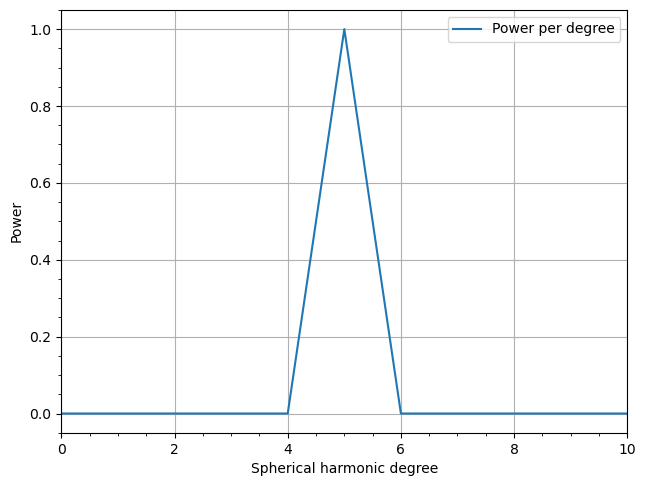

In [298]:
fig, ax = coeffs_l5m2.plot_spectrum(xscale='lin', yscale='lin',  lmax = 10, show=False)

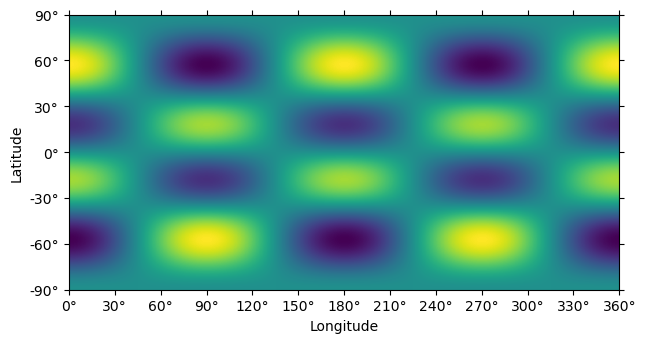

In [300]:
grid_l5m2 = coeffs_l5m2.expand(grid='DH')
fig, ax = grid_l5m2.plot(show=False)

In [302]:
grid_l5m2

  name = None
  kind = 'real'
  grid = 'DH'
  n = 402
  sampling = 1
  extend = True
  nlat = 403
  nlon = 403
  lmax = 200
  units = None